In [2]:
from google.colab import files

uploaded = files.upload()


Saving Ecommerce_Return_Investigation_Dataset.csv to Ecommerce_Return_Investigation_Dataset.csv


In [3]:
import pandas as pd

df = pd.read_csv('/content/Ecommerce_Return_Investigation_Dataset.csv')

In [4]:
df.head()

,Order_ID,Customer_ID,Product_Category,Product_Price,Discount_Percent,Delivery_Days,Customer_Rating,Return_Status,Return_Reason
0,ORD100000,CUST10285,Home,3043.56,10,7,4.4,Not Returned,Not Returned
1,ORD100001,CUST10048,Books,4158.47,0,4,4.3,Not Returned,Not Returned
2,ORD100002,CUST10139,Fashion,1869.48,20,13,3.2,Not Returned,Not Returned
3,ORD100003,CUST10217,Electronics,3454.48,20,11,3.8,Returned,Wrong Size
4,ORD100004,CUST10043,Electronics,2915.51,15,8,2.3,Not Returned,Not Returned


In [5]:
df.shape

(1000, 9)

In [6]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Product_Category,0
Product_Price,0
Discount_Percent,0
Delivery_Days,0
Customer_Rating,0
Return_Status,0
Return_Reason,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
total_orders = len(df)
print("Total Orders:", total_orders)

Total Orders: 1000


In [9]:
returned_products = (df['Return_Status'] == 'Returned').sum()
print(returned_products)

211


In [10]:
return_percentage = (returned_products / total_orders) * 100

print("Return Percentage:", round(return_percentage, 2), "%")

Return Percentage: 21.1 %


In [11]:
df[['Product_Price','Delivery_Days','Customer_Rating']].mean()

,0
Product_Price,2618.63433
Delivery_Days,7.44300
Customer_Rating,2.99910


In [12]:
df[['Product_Price','Delivery_Days','Customer_Rating']].median()

,0
Product_Price,2685.9
Delivery_Days,7.0
Customer_Rating,3.0


In [13]:
df[['Product_Price','Delivery_Days','Customer_Rating']].std()

,0
Product_Price,1394.469329
Delivery_Days,4.113596
Customer_Rating,1.158754


In [14]:
df[['Product_Price','Delivery_Days','Customer_Rating']].quantile([0.25,0.5,0.75])

,Product_Price,Delivery_Days,Customer_Rating
0.25,1366.995,4.0,2.1
0.50,2685.900,7.0,3.0
0.75,3824.475,11.0,4.0


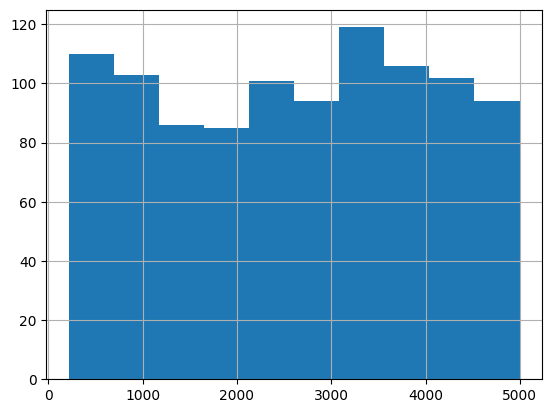

In [15]:
import matplotlib.pyplot as plt

df['Product_Price'].hist()
plt.show()

In [16]:
print(pd.crosstab(df['Product_Category'], df['Return_Status']))

Return_Status     Not Returned  Returned
Product_Category                        
Beauty                     131        26
Books                      145        33
Electronics                122        43
Fashion                    126        32
Home                       125        40
Sports                     140        37


In [17]:
print(df.groupby('Return_Status')['Product_Price'].mean())

Return_Status
Not Returned    2616.518061
Returned        2626.547773
Name: Product_Price, dtype: float64


In [18]:
print(df.groupby('Return_Status')['Delivery_Days'].mean())

Return_Status
Not Returned    7.193916
Returned        8.374408
Name: Delivery_Days, dtype: float64


In [19]:
print(df.groupby('Return_Status')['Discount_Percent'].mean())

Return_Status
Not Returned    16.121673
Returned        20.426540
Name: Discount_Percent, dtype: float64


In [20]:
print(df.groupby('Return_Status')['Customer_Rating'].mean())

Return_Status
Not Returned    3.089354
Returned        2.661611
Name: Customer_Rating, dtype: float64


<Axes: xlabel='Product_Category'>

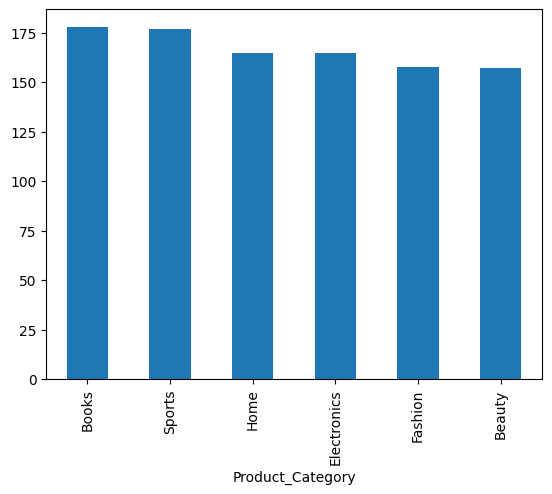

In [21]:
df['Product_Category'].value_counts().plot(kind='bar')

<Axes: >

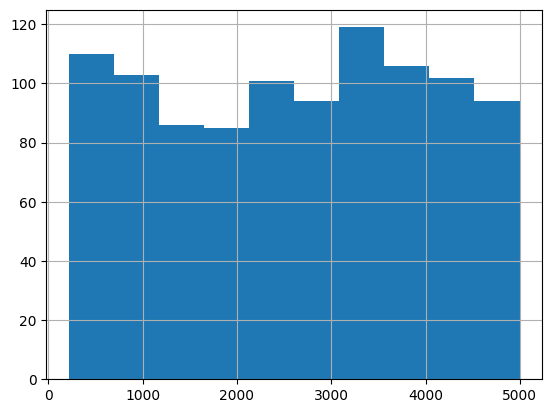

In [22]:
df['Product_Price'].hist()

<Axes: >

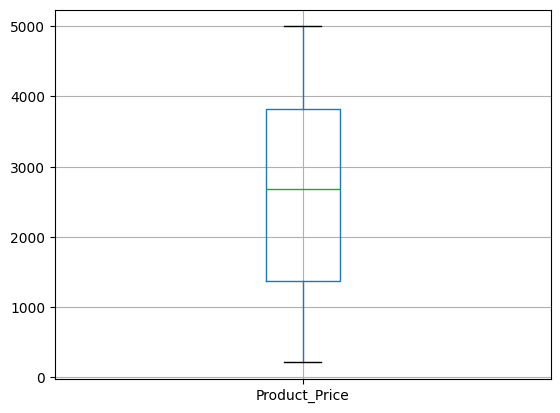

In [23]:
df.boxplot(column='Product_Price')

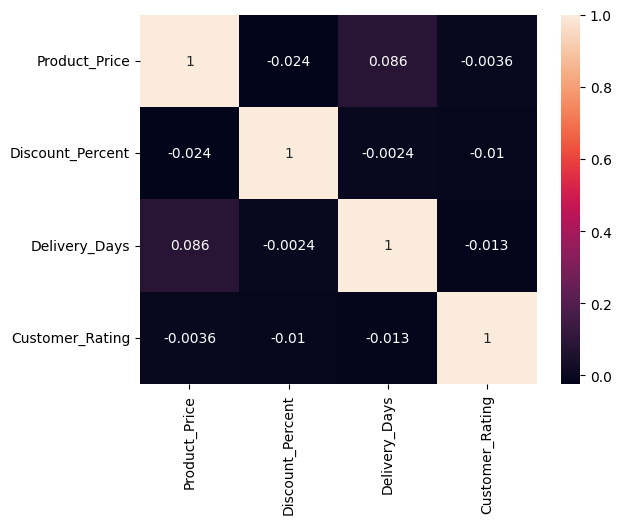

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

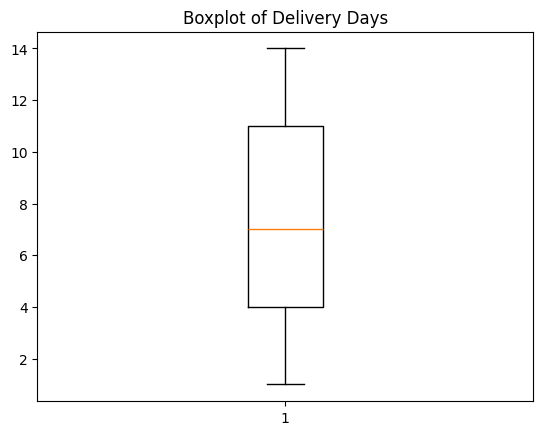

In [25]:
import matplotlib.pyplot as plt

plt.boxplot(df['Delivery_Days'])
plt.title("Boxplot of Delivery Days")
plt.show()

In [26]:
Q1 = df['Product_Price'].quantile(0.25)
Q3 = df['Product_Price'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df['Product_Price'] < Q1 - 1.5*IQR) |
              (df['Product_Price'] > Q3 + 1.5*IQR)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 0


In [27]:
from scipy.stats import zscore

z_scores = zscore(df['Delivery_Days'])
outliers = df[abs(z_scores) > 3]

print("Outliers:", len(outliers))

Outliers: 0


In [28]:
from scipy.stats import ttest_ind

returned = df[df['Return_Status'] == 'Returned']['Delivery_Days']
not_returned = df[df['Return_Status'] == 'Not Returned']['Delivery_Days']

t_stat, p_value = ttest_ind(returned, not_returned)

print("P-value:", p_value)

P-value: 0.00020503569740712506


In [29]:
from scipy.stats import f_oneway

electronics = df[df['Product_Category']=='Electronics']['Delivery_Days']
fashion = df[df['Product_Category']=='Fashion']['Delivery_Days']
home = df[df['Product_Category']=='Home']['Delivery_Days']

f_stat, p_value = f_oneway(electronics, fashion, home)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 0.058306783642806594
P-value: 0.9433671070620259


In [30]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['Product_Category'], df['Return_Status'])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-Square Value:", chi2)
print("P-value:", p_value)

Chi-Square Value: 6.134204615961354
P-value: 0.2933784385147459


In [31]:
high_return = df[df['Return_Status'] == 'Returned']
print(high_return['Customer_ID'].value_counts())

Customer_ID
CUST10225    4
CUST10097    3
CUST10018    3
CUST10254    3
CUST10293    3
            ..
CUST10008    1
CUST10184    1
CUST10057    1
CUST10051    1
CUST10288    1
Name: count, Length: 150, dtype: int64


In [32]:
discount_customers = df[df['Discount_Percent'] >= 30]
print(discount_customers.head())

     Order_ID Customer_ID Product_Category  Product_Price  Discount_Percent  \
13  ORD100013   CUST10233            Books        3547.86                30   
17  ORD100017   CUST10278             Home         961.30                30   
22  ORD100022   CUST10186             Home         818.58                40   
24  ORD100024   CUST10182           Beauty        3768.84                40   
25  ORD100025   CUST10267            Books         971.65                40   

    Delivery_Days  Customer_Rating Return_Status Return_Reason  
13              8              3.8  Not Returned  Not Returned  
17              8              1.6  Not Returned  Not Returned  
22              8              3.5      Returned     Defective  
24             14              4.4  Not Returned  Not Returned  
25              6              2.9  Not Returned  Not Returned  


In [33]:
premium_customers = df[df['Product_Price'] > 3000]
print(premium_customers.head())

    Order_ID Customer_ID Product_Category  Product_Price  Discount_Percent  \
0  ORD100000   CUST10285             Home        3043.56                10   
1  ORD100001   CUST10048            Books        4158.47                 0   
3  ORD100003   CUST10217      Electronics        3454.48                20   
6  ORD100006   CUST10077            Books        4417.42                 0   
7  ORD100007   CUST10215             Home        4027.64                 5   

   Delivery_Days  Customer_Rating Return_Status Return_Reason  
0              7              4.4  Not Returned  Not Returned  
1              4              4.3  Not Returned  Not Returned  
3             11              3.8      Returned    Wrong Size  
6              5              4.3  Not Returned  Not Returned  
7              7              2.8  Not Returned  Not Returned  


In [34]:
delayed_customers = df[df['Delivery_Days'] > 7]
print(delayed_customers.head())

    Order_ID Customer_ID Product_Category  Product_Price  Discount_Percent  \
2  ORD100002   CUST10139          Fashion        1869.48                20   
3  ORD100003   CUST10217      Electronics        3454.48                20   
4  ORD100004   CUST10043      Electronics        2915.51                15   
5  ORD100005   CUST10268           Sports        1481.74                 5   
8  ORD100008   CUST10097      Electronics        3360.57                 0   

   Delivery_Days  Customer_Rating Return_Status Return_Reason  
2             13              3.2  Not Returned  Not Returned  
3             11              3.8      Returned    Wrong Size  
4              8              2.3  Not Returned  Not Returned  
5             13              2.9  Not Returned  Not Returned  
8             10              2.4      Returned  Changed Mind  


In [35]:
low_rating = df[df['Customer_Rating'] < 3]
print(low_rating.head())

     Order_ID Customer_ID Product_Category  Product_Price  Discount_Percent  \
4   ORD100004   CUST10043      Electronics        2915.51                15   
5   ORD100005   CUST10268           Sports        1481.74                 5   
7   ORD100007   CUST10215             Home        4027.64                 5   
8   ORD100008   CUST10097      Electronics        3360.57                 0   
11  ORD100011   CUST10148           Beauty        3600.14                20   

    Delivery_Days  Customer_Rating Return_Status Return_Reason  
4               8              2.3  Not Returned  Not Returned  
5              13              2.9  Not Returned  Not Returned  
7               7              2.8  Not Returned  Not Returned  
8              10              2.4      Returned  Changed Mind  
11             11              2.3      Returned  Changed Mind  
